# Boosted Regression Tree (BRT) Periyar - Flood

In [5]:
! pip install mlxtend

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [7]:
# Load and balance dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Flood_ML_CSV.csv"

df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'DistToRoads1', 'DistToStreams1', 'Elevation1',
       'FlowDir1', 'Geomorphology1', 'LULC1', 'NDBI1', 'NDVI1', 'NDWI1',
       'PlanarCurv1', 'Rainfall1', 'Rainfall2', 'Rainfall3', 'Rainfall4',
       'Rainfall5', 'Rainfall6', 'Rainfall7', 'Rainfall8', 'Rainfall9',
       'Rainfall10', 'Rainfall11', 'Slope1', 'SPI1', 'TPI1', 'TRI1', 'WRI1',
       'Target_Var'],
      dtype='object')


In [8]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 2940
Total Columns: 29

First 5 Rows:
                                            wkt_geom   Aspect1  DistToRoads1  \
0  PointZ (732440.63698526588268578 1099235.47889...  0.402733      0.000000   
1  PointZ (674839.43473400757648051 1124917.48835...  0.090366    254.561630   
2  PointZ (660814.79396556201390922 1125920.42624...  0.325709     30.002138   
3  PointZ (734648.83889931708108634 1065001.68916...  0.256483    239.930328   
4  PointZ (666991.70427034259773791 1126960.97581...  0.903562    300.016357   

   DistToStreams1  Elevation1  FlowDir1  Geomorphology1  LULC1     NDBI1  \
0      134.164078    0.447464  0.403900               1     10  0.330127   
1       90.000000    0.040280  0.089136               1     10  0.342821   
2      234.307495    0.089385  0.324930               1     10  0.335920   
3       42.426407    0.521028  0.256267               1     10  0.271296   
4      180.000000    0.119403  0.902507               1     10  0.394805   

      NDVI1 

Features (X) Shape: (2940, 27)
Target (y) Shape: (2940,)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Accuracy: 0.8832
Precision: 0.8837
Recall: 0.8832

Confusion Matrix:
 [[382  59]
 [ 44 397]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       441
           1       0.87      0.90      0.89       441

    accuracy                           0.88       882
   macro avg       0.88      0.88      0.88       882
weighted avg       0.88      0.88      0.88       882



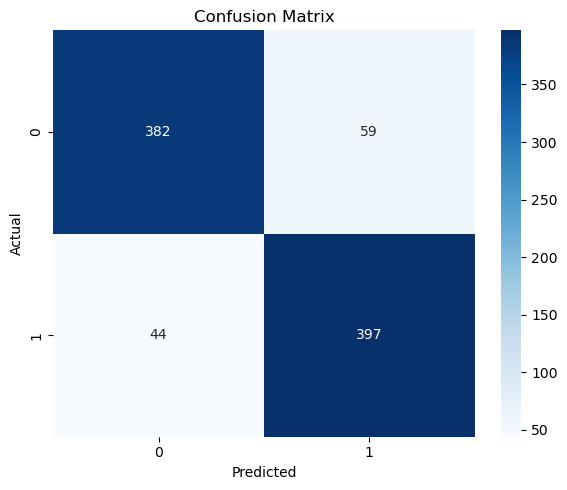

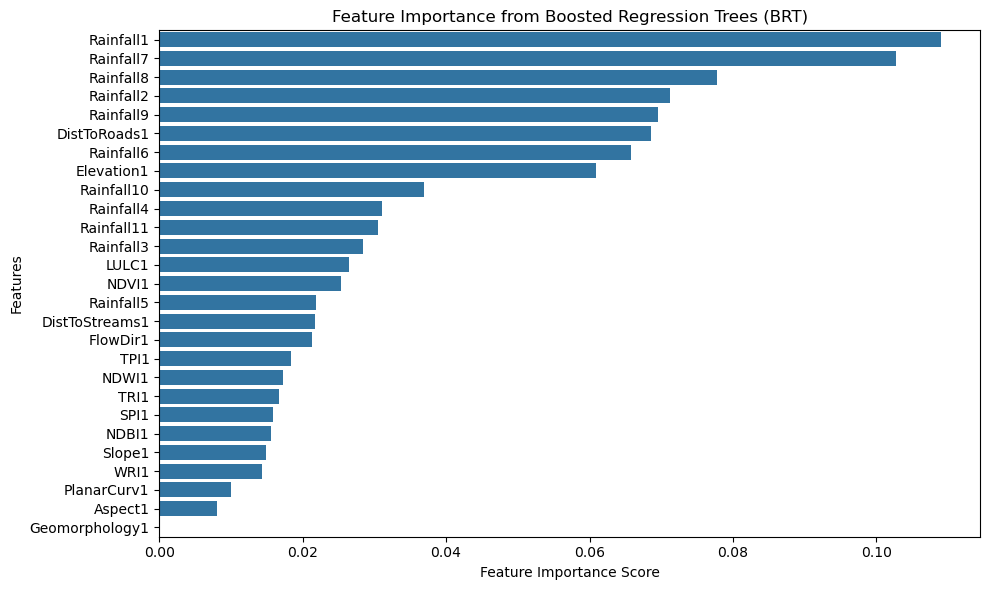

In [9]:
# ==== IMPORTS ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

# ==== DATA PREPARATION ====

# Define target column
target_column = "Target_Var"

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fill missing values with zero
df = df.fillna(0)

# Define features and labels
X = df.drop(columns=[target_column, "wkt_geom"])
y = df[target_column]

# Display shapes
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ==== TRAIN-TEST SPLIT ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== HYPERPARAMETER GRID ====
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

brt = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=brt,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# ==== RUN GRID SEARCH ====
grid_search.fit(X_train, y_train)

# Retrieve best model
best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# ==== MAKE PREDICTIONS ====
y_pred = best_model.predict(X_test)

# ==== METRICS ====
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

# ==== PLOT CONFUSION MATRIX ====
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ==== FEATURE IMPORTANCE PLOT ====
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from Boosted Regression Trees (BRT)')
plt.tight_layout()
plt.show()


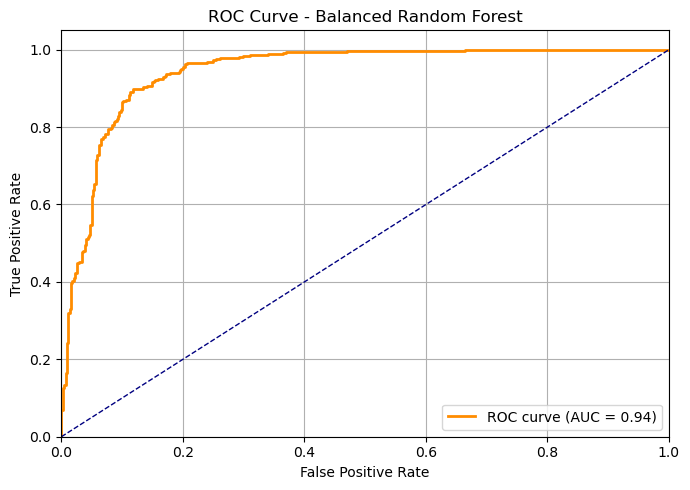

In [10]:
# ==== ROC CURVE FOR BINARY CLASSIFICATION ====
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_score = best_model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_test, y_score)

# Compute AUC (Area Under Curve)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Balanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
! pip install shap imbalanced-learn pandas scikit-learn matplotlib seaborn

In [12]:
import pandas as pd

# Create DataFrame
df_brt = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Prob': y_score,         # Probabilities of class 1
    'Predicted_Label': y_pred          # Final predicted labels
})

# Save path
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\BRT_Flood_Results.csv"
df_brt.to_csv(save_path, index=False)


In [13]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier


# SHAP Explanation using Permutation Explainer (Recommended for ensemble models)
explainer = shap.Explainer(brt.predict, X_train, algorithm="permutation")
shap_values = explainer(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

# SHAP Bar Plot (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Dependence Plot (for the most important feature)
most_important_feature = X.columns[np.argmax(np.abs(shap_values.values).mean(axis=0))]
shap.dependence_plot(most_important_feature, shap_values.values, X_test)

# Show plots
plt.show()

NotFittedError: This GradientBoostingClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.